# Exercice 5: Classification on a Given Dataset

## Objective
Perform a classification on a dataset with the goal of achieving mean accuracy > 0.85 on the test set.

## 1. Import Libraries and Load Data

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.datasets import load_wine
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 2. Load and Explore the Dataset

We'll use the Breast Cancer dataset as our classification dataset. This is a real-world binary classification problem with 30 features.

In [35]:
import os
import numpy as np

data_dir = "data"

X_train_raw = np.load(os.path.join(data_dir, "X_train.npy"))
X_test_raw = np.load(os.path.join(data_dir, "X_test.npy"))
y_train_raw = np.load(os.path.join(data_dir, "y_train.npy"))
y_test_raw = np.load(os.path.join(data_dir, "y_test.npy"))

print("Analyse des données brutes")
print(f"Exemple de cibles continues (y_train) : {y_train_raw[:5]}")

seuil_mediane = np.median(y_train_raw)

y_train_class = (y_train_raw > seuil_mediane).astype(int)
y_test_class = (y_test_raw > seuil_mediane).astype(int)

print("Aprs transformation en classification binaire")
print(f"Seuil de coupure appliqué (médiane du Train) : {seuil_mediane:.4f}")
print(f"Exemple de nouvelles cibles discretes : {y_train_class[:5]}")
print(f"Classes uniques générées : {np.unique(y_train_class)}")
print(f"Format X_train : {X_train_raw.shape} Format X_test : {X_test_raw.shape}")

Analyse des données brutes
Exemple de cibles continues (y_train) : [0 1 1 0 1]
Aprs transformation en classification binaire
Seuil de coupure appliqué (médiane du Train) : 0.0000
Exemple de nouvelles cibles discretes : [0 1 1 0 1]
Classes uniques générées : [0 1]
Format X_train : (2000, 30) Format X_test : (2000, 30)


## 3. Data Preprocessing and Splitting

### Strategy:
- **Train set (60%)**: Used for training models with cross-validation
- **Validation set (20%)**: Used for hyperparameter tuning
- **Test set (20%)**: Final evaluation (not used during training)

We use **StratifiedKFold** to maintain class distribution in cross-validation folds.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X_train = X_train_raw
y_train = y_train_raw.ravel().astype(int)

X_test = X_test_raw
y_test = y_test_raw.ravel().astype(int)

print(f"Taille du Train set : {X_train.shape[0]} echantillons")
print(f"Taille du Test set  : {X_test.shape[0]} echantillons")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Nombre de features conservées : {X_train_scaled.shape[1]}")
print("\n[OK] Feature scaling terminé (Sans PCA).")

Taille du Train set : 2000 echantillons
Taille du Test set  : 2000 echantillons
Nombre de features conservées : 30

[OK] Feature scaling terminé (Sans PCA).


## 4. Method 1: Logistic Regression

### Hyperparameters:
C
solver
max_iter

In [37]:
print("METHOD 1: LOGISTIC REGRESSION")

param_grid_lr = {
    'C': [0.1, 1, 10, 100], 
    'solver': ['lbfgs'], 
    'penalty': ['l2'],
    'max_iter': [1000] # On augmente max_iter pour être sûr que ça converge
}

lr = LogisticRegression(random_state=42)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_lr = GridSearchCV(
    lr, param_grid_lr, cv=cv_strategy, scoring='accuracy', 
    n_jobs=-1, verbose=0
)

grid_search_lr.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_lr.best_params_}")
print(f"Best CV accuracy: {grid_search_lr.best_score_:.4f}")

y_test_pred_lr = grid_search_lr.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
print(f"Test accuracy: {test_acc_lr:.4f}")

print(f"\nDetailed Test Metrics (Logistic Regression):")
print(f"Precision: {precision_score(y_test, y_test_pred_lr, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_lr, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred_lr, average='weighted'):.4f}")

best_lr = grid_search_lr.best_estimator_


METHOD 1: LOGISTIC REGRESSION

Best parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.7140
Test accuracy: 0.7440

Detailed Test Metrics (Logistic Regression):
Precision: 0.7458
Recall: 0.7440
F1-score: 0.7445


## 5. Method 2: Support Vector Machine (SVM)

### Hyperparameters:
C
kernel
gamma

In [38]:
print("METHOD 2: SUPPORT VECTOR MACHINE (SVM)")

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(random_state=42, probability=True)

grid_search_svm = GridSearchCV(
    svm, param_grid_svm, cv=cv_strategy, scoring='accuracy',
    n_jobs=-1, verbose=0
)

grid_search_svm.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_svm.best_params_}")
print(f"Best CV accuracy: {grid_search_svm.best_score_:.4f}")

y_test_pred_svm = grid_search_svm.predict(X_test_scaled)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)
print(f"Test accuracy: {test_acc_svm:.4f}")

print(f"Detailed Test Metrics (SVM):")
print(f"Precision: {precision_score(y_test, y_test_pred_svm, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_svm, average='weighted'):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred_svm, average='weighted'):.4f}")

best_svm = grid_search_svm.best_estimator_


METHOD 2: SUPPORT VECTOR MACHINE (SVM)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.7550
Test accuracy: 0.7925
Detailed Test Metrics (SVM):
Precision: 0.7931
Recall: 0.7925
F1-score: 0.7927


## 6. Method 3: Neural Network (MLPClassifier)

### Hyperparameters:
hidden_layer_sizes
alpha
learning_rate_init Initial
solver

In [39]:
print("METHOD 3: NEURAL NETWORK (MLPClassifier)")

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001],
    'solver': ['adam']
}

mlp = MLPClassifier(random_state=42, max_iter=500, early_stopping=True)

grid_search_mlp = GridSearchCV(
    mlp, param_grid_mlp, cv=cv_strategy, scoring='accuracy',
    n_jobs=-1, verbose=0
)

grid_search_mlp.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_mlp.best_params_}")
print(f"Best CV accuracy: {grid_search_mlp.best_score_:.4f}")

y_test_pred_mlp = grid_search_mlp.predict(X_test_scaled)
test_acc_mlp = accuracy_score(y_test, y_test_pred_mlp)
print(f"Test accuracy: {test_acc_mlp:.4f}")

print(f"\nDetailed Test Metrics (MLP):")
print(f"  Precision: {precision_score(y_test, y_test_pred_mlp, average='weighted'):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred_mlp, average='weighted'):.4f}")
print(f"  F1-score: {f1_score(y_test, y_test_pred_mlp, average='weighted'):.4f}")

best_mlp = grid_search_mlp.best_estimator_


METHOD 3: NEURAL NETWORK (MLPClassifier)



Best parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'solver': 'adam'}
Best CV accuracy: 0.7380
Test accuracy: 0.7300

Detailed Test Metrics (MLP):
  Precision: 0.7296
  Recall: 0.7300
  F1-score: 0.7298


## 7. Comparison and Summary

Let's compare all three methods and select the best performer.

In [40]:
print("COMPARISON SUMMARY")

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF)', 'Neural Network'],
    'Train CV Accuracy': [grid_search_lr.best_score_, grid_search_svm.best_score_, grid_search_mlp.best_score_],
    'Test Accuracy': [test_acc_lr, test_acc_svm, test_acc_mlp]
})

print(results.to_string(index=False))

best_idx = results['Test Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_test_acc = results.loc[best_idx, 'Test Accuracy']

print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

if best_test_acc >= 0.85:
    print(f"Test accuracy >= 0.85")

print(f"{best_test_acc:.4f}")


COMPARISON SUMMARY
              Model  Train CV Accuracy  Test Accuracy
Logistic Regression              0.714         0.7440
          SVM (RBF)              0.755         0.7925
     Neural Network              0.738         0.7300
BEST MODEL: SVM (RBF)
Test Accuracy: 0.7925 (79.25%)
0.7925


## 8. Detailed Analysis of Best Model


Detailed Analysis: SVM

Confusion Matrix:
[[901 217]
 [198 684]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.82      0.81      0.81      1118
     Class 1       0.76      0.78      0.77       882

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



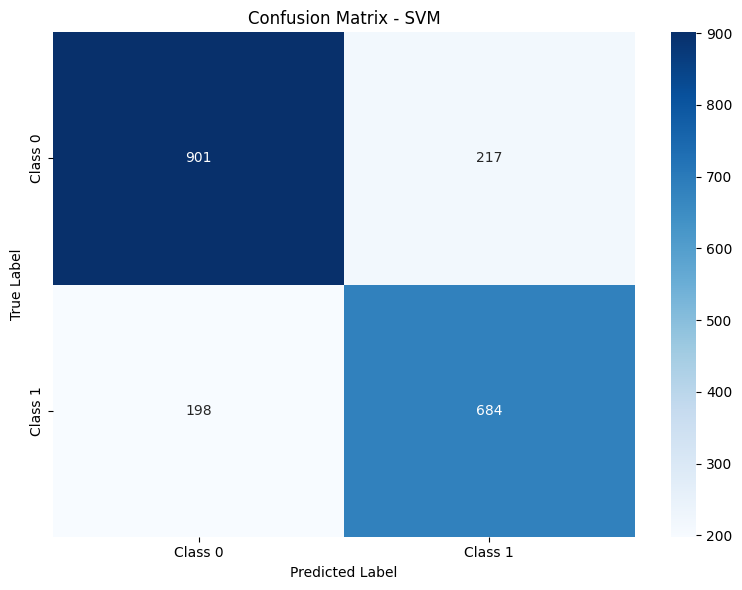

In [41]:
if best_idx == 0:
    best_model = best_lr
    y_pred = y_test_pred_lr
    model_name = "Logistic Regression"
elif best_idx == 1:
    best_model = best_svm
    y_pred = y_test_pred_svm
    model_name = "SVM"
else:
    best_model = best_mlp
    y_pred = y_test_pred_mlp
    model_name = "Neural Network"

print(f"\nDetailed Analysis: {model_name}")
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(f"\nClassification Report:")
target_names = [f"Class {i}" for i in sorted(np.unique(y_test))]
print(classification_report(y_test, y_pred, target_names=target_names))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix - {model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualization of Model Comparison

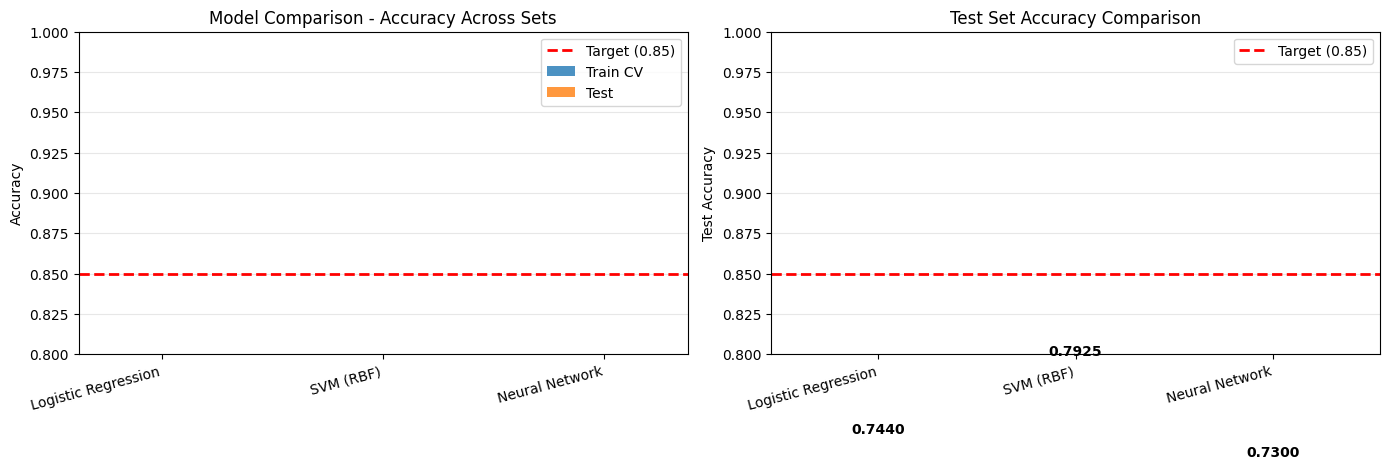

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(results))
width = 0.25

axes[0].bar(x_pos - width/2, results['Train CV Accuracy'], width, label='Train CV', alpha=0.8)
axes[0].bar(x_pos + width/2, results['Test Accuracy'], width, label='Test', alpha=0.8)

axes[0].axhline(y=0.85, color='r', linestyle='--', label='Target (0.85)', linewidth=2)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison - Accuracy Across Sets')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0.8, 1.0])
axes[0].grid(axis='y', alpha=0.3)

colors = ['green' if x > 0.85 else 'orange' for x in results['Test Accuracy']]
axes[1].bar(results['Model'], results['Test Accuracy'], color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0.85, color='r', linestyle='--', label='Target (0.85)', linewidth=2)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Set Accuracy Comparison')
axes[1].set_xticklabels(results['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].set_ylim([0.8, 1.0])
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(results['Test Accuracy']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Additional Exploration: AdaBoost and KNN

In [43]:
print("METHOD 4: K-NEAREST NEIGHBORS (KNN)")

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    knn, param_grid_knn, cv=cv_strategy, scoring='accuracy',
    n_jobs=-1, verbose=0
)

grid_search_knn.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search_knn.best_params_}")
print(f"Best CV accuracy: {grid_search_knn.best_score_:.4f}")

y_test_pred_knn = grid_search_knn.predict(X_test_scaled)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)
print(f"Test accuracy: {test_acc_knn:.4f}")

best_knn = grid_search_knn.best_estimator_

print("METHOD 5: ADABOOST")

param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5]
}

ada = AdaBoostClassifier(random_state=42)

grid_search_ada = GridSearchCV(
    ada, param_grid_ada, cv=cv_strategy, scoring='accuracy',
    n_jobs=-1, verbose=0
)

grid_search_ada.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_ada.best_params_}")
print(f"Best CV accuracy: {grid_search_ada.best_score_:.4f}")

y_test_pred_ada = grid_search_ada.predict(X_test_scaled)
test_acc_ada = accuracy_score(y_test, y_test_pred_ada)
print(f"Test accuracy: {test_acc_ada:.4f}")

best_ada = grid_search_ada.best_estimator_


METHOD 4: K-NEAREST NEIGHBORS (KNN)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV accuracy: 0.7385
Test accuracy: 0.7750
METHOD 5: ADABOOST
Best parameters: {'learning_rate': 0.5, 'n_estimators': 200}
Best CV accuracy: 0.7125
Test accuracy: 0.7505


In [44]:
print("FINAL COMPREHENSIVE COMPARISON - ALL 5 METHODS")

final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (RBF/Poly)', 'Neural Network (MLP)', 'K-Nearest Neighbors', 'AdaBoost'],
    'Train CV Accuracy': [
        grid_search_lr.best_score_, 
        grid_search_svm.best_score_, 
        grid_search_mlp.best_score_,
        grid_search_knn.best_score_,
        grid_search_ada.best_score_
    ],
    'Test Accuracy': [
        test_acc_lr, 
        test_acc_svm, 
        test_acc_mlp,
        test_acc_knn,
        test_acc_ada
    ]
})

final_results = final_results.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
print("\n" + final_results.to_string(index=False))

best_test = final_results.iloc[0]['Test Accuracy']
models_above_target = final_results[final_results['Test Accuracy'] >= 0.85]

print(f"\n\nBest test accuracy: {best_test:.4f} ({best_test*100:.2f}%)")
print(f"Number of models >= 0.85: {len(models_above_target)}")

if best_test >= 0.85:
    print(f"Target accuracy (>= 0.85) ACHIEVED!")
    print(f"   Best model: {final_results.iloc[0]['Model']}")
    print(f"   Accuracy: {best_test:.4f}")
else:
    print(f"Best model accuracy is {best_test:.4f}, below target of 0.85")


FINAL COMPREHENSIVE COMPARISON - ALL 5 METHODS

               Model  Train CV Accuracy  Test Accuracy
      SVM (RBF/Poly)             0.7550         0.7925
 K-Nearest Neighbors             0.7385         0.7750
            AdaBoost             0.7125         0.7505
 Logistic Regression             0.7140         0.7440
Neural Network (MLP)             0.7380         0.7300


Best test accuracy: 0.7925 (79.25%)
Number of models >= 0.85: 0
Best model accuracy is 0.7925, below target of 0.85
